Preemptive SJF Results
PID  AT  BT  CT  WT  TAT
 P1   6   3  12   3    6
 P2  10   6  18   2    8
 P3   1   4   6   1    5
 P4   2   3   9   4    7
 P5   3   1   4   0    1
Average Waiting Time:    2.00
Average Turnaround Time: 5.40


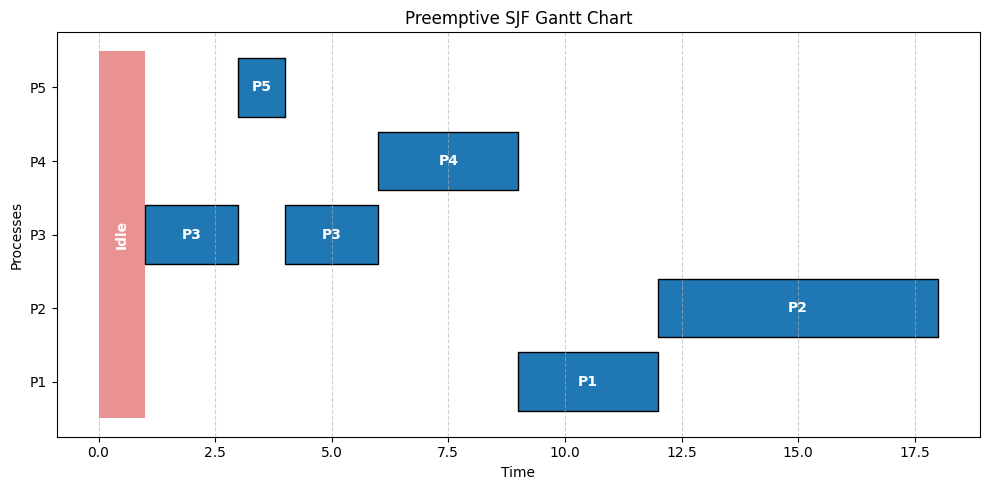

In [3]:
import random
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Input Section ---
processes = []

n = int(input("Enter number of processes: "))
for i in range(n):
    bt = random.randint(1, 10)
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': bt,
        'RT': bt,  # Remaining Time
        'Completed': False
    })

# --- 2. Calculation Logic ---
current_time = 0
completed_count = 0
timeline = [] 
total_tat = 0
total_wt = 0

# Helper to keep the Gantt chart clean (merges consecutive 1-second blocks)
def record_history(label, start, end):
    if not timeline:
        timeline.append((label, start, end))
        return
    last_lbl, last_start, last_end = timeline[-1]
    
    if last_lbl == label and last_end == start:
        timeline[-1] = (label, last_start, end) # Extend previous block
    else:
        timeline.append((label, start, end))

while completed_count < n:
    # Find available processes that still have remaining time
    available = [p for p in processes if p['AT'] <= current_time and not p['Completed']]

    if not available:
        record_history('Idle', current_time, current_time + 1)
        current_time += 1
        continue

    # SRTF CORE LOGIC: Pick process with Minimum Remaining Time (RT)
    # Tie-breaker: If RT is equal, pick the one with earlier Arrival Time
    shortest_job = min(available, key=lambda x: (x['RT'], x['AT']))

    # Run for 1 unit of time
    shortest_job['RT'] -= 1
    record_history(shortest_job['PID'], current_time, current_time + 1)
    
    current_time += 1

    # Check if process is now finished
    if shortest_job['RT'] == 0:
        shortest_job['Completed'] = True
        completed_count += 1
        
        shortest_job['CT'] = current_time
        shortest_job['TAT'] = shortest_job['CT'] - shortest_job['AT']
        shortest_job['WT'] = shortest_job['TAT'] - shortest_job['BT']
        
        total_tat += shortest_job['TAT']
        total_wt += shortest_job['WT']

avg_tat = total_tat / n
avg_wt = total_wt / n

# --- 3. Output Table ---
df = pd.DataFrame(processes)
df = df[['PID', 'AT', 'BT', 'CT','WT','TAT']].sort_values(by='PID')

print("Preemptive SJF Results")
print(df.to_string(index=False))
print(f"Average Waiting Time:    {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(10, 5))
unique_pids = df['PID'].unique()
y_pos = {pid: i for i, pid in enumerate(unique_pids)}

for label, start, end in timeline:
    duration = end - start
    if duration <= 0: continue
    
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(unique_pids)), facecolors='tab:red', alpha=0.5)
        ax.text(start + duration/2, len(unique_pids)/2 - 0.5, "Idle", ha='center', va='center', rotation=90
                , color='white', fontweight='bold')
    else:
        y = y_pos[label]
        ax.broken_barh([(start, duration)], (y - 0.4, 0.8), facecolors='tab:blue', edgecolor='black')
        ax.text(start + duration/2, y, label, ha='center', va='center', color='white', fontweight='bold')


ax.set_yticks(range(len(unique_pids)))
ax.set_yticklabels(unique_pids)
ax.set_xlabel('Time')
ax.set_ylabel('Processes')
ax.set_title('Preemptive SJF Gantt Chart')
ax.grid(True, axis='x', linestyle='--', alpha = 0.6)
plt.tight_layout()
plt.show()

Preemptive SJF Results
PID  AT  BT  CT  WT  TAT
 P1   1   2   3   0    2
 P2   4   2   6   0    2
 P3   2   6  11   3    9
 P4   8   7  29  14   21
 P5   2   6  22  14   20
 P6   6   5  16   5   10
Average Waiting Time:    6.00
Average Turnaround Time: 10.67


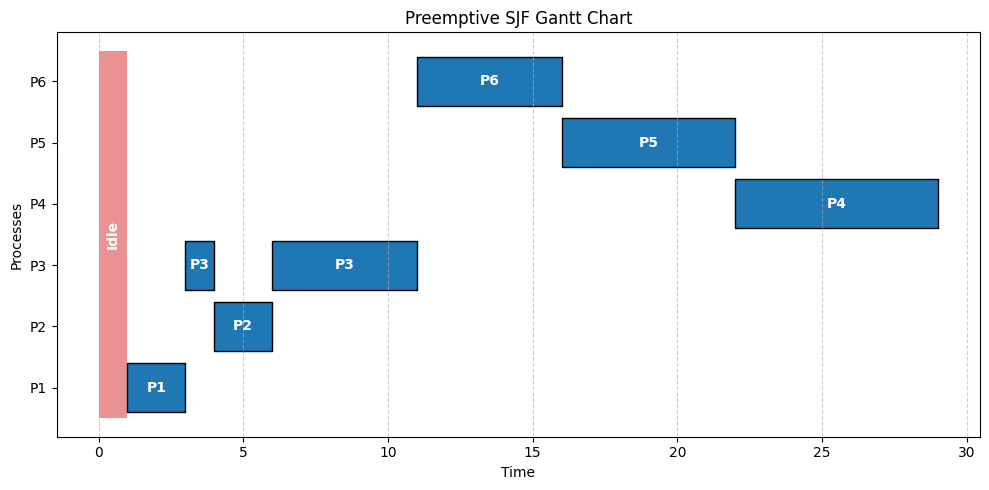

In [6]:
import random
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Input Section ---
processes = []

n = int(input("Enter number of processes: "))
for i in range(n):
    bt = random.randint(1, 10)
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': bt,
        'RT': bt,  # Remaining Time
        'Completed': False
    })

# --- 2. Calculation Logic ---
current_time = 0
completed_count = 0
timeline = [] 
total_tat = 0
total_wt = 0

# Helper to keep the Gantt chart clean (merges consecutive 1-second blocks)
def record_history(label, start, end):
    if not timeline:
        timeline.append((label, start, end))
        return
    last_lbl, last_start, last_end = timeline[-1]
    
    if last_lbl == label and last_end == start:
        timeline[-1] = (label, last_start, end) # Extend previous block
    else:
        timeline.append((label, start, end))

while completed_count < n:
    # Find available processes that still have remaining time
    available = [p for p in processes if p['AT'] <= current_time and not p['Completed']]

    if not available:
        record_history('Idle', current_time, current_time + 1)
        current_time += 1
        continue

    # SRTF CORE LOGIC: Pick process with Minimum Remaining Time (RT)
    # Tie-breaker: If RT is equal, pick the one with earlier Arrival Time
    shortest_job = min(available, key=lambda x: (x['RT'], x['AT']))

    # Run for 1 unit of time
    shortest_job['RT'] -= 1
    record_history(shortest_job['PID'], current_time, current_time + 1)
    
    current_time += 1

    # Check if process is now finished
    if shortest_job['RT'] == 0:
        shortest_job['Completed'] = True
        completed_count += 1
        
        shortest_job['CT'] = current_time
        shortest_job['TAT'] = shortest_job['CT'] - shortest_job['AT']
        shortest_job['WT'] = shortest_job['TAT'] - shortest_job['BT']
        
        total_tat += shortest_job['TAT']
        total_wt += shortest_job['WT']

avg_tat = total_tat / n
avg_wt = total_wt / n

# --- 3. Output Table ---
df = pd.DataFrame(processes)
df = df[['PID', 'AT', 'BT', 'CT','WT','TAT']].sort_values(by='PID')

print("Preemptive SJF Results")
print(df.to_string(index=False))
print(f"Average Waiting Time:    {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(10, 5))
unique_pids = df['PID'].unique()
y_pos = {pid: i for i, pid in enumerate(unique_pids)}

for label, start, end in timeline:
    duration = end - start
    if duration <= 0: continue
    
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(unique_pids)), facecolors='tab:red', alpha=0.5)
        ax.text(start + duration/2, len(unique_pids)/2 - 0.5, "Idle", ha='center', va='center', rotation=90
                , color='white', fontweight='bold')
    else:
        y = y_pos[label]
        ax.broken_barh([(start, duration)], (y - 0.4, 0.8), facecolors='tab:blue', edgecolor='black')
        ax.text(start + duration/2, y, label, ha='center', va='center', color='white', fontweight='bold')


ax.set_yticks(range(len(unique_pids)))
ax.set_yticklabels(unique_pids)
ax.set_xlabel('Time')
ax.set_ylabel('Processes')
ax.set_title('Preemptive SJF Gantt Chart')
ax.grid(True, axis='x', linestyle='--', alpha = 0.6)
plt.tight_layout()
plt.show()